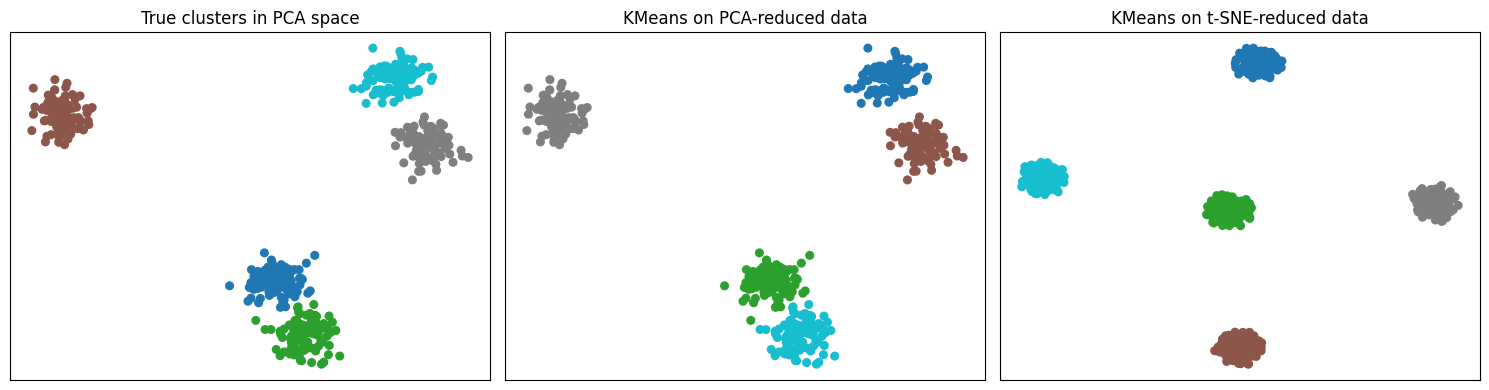

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

# generate synthetic high-dimensional data
X, y_true = make_blobs(
    n_samples=500,
    n_features=50,
    centers=5,
    cluster_std=2.5,
    random_state=42,
)

# reduce dimensionality
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X)

# cluster in reduced space
kmeans_pca = KMeans(n_clusters=5, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

kmeans_tsne = KMeans(n_clusters=5, random_state=42)
labels_tsne = kmeans_tsne.fit_predict(X_tsne)

# plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="tab10", s=30)
axes[0].set_title("True clusters in PCA space")
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap="tab10", s=30)
axes[1].set_title("KMeans on PCA-reduced data")
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_tsne, cmap="tab10", s=30)
axes[2].set_title("KMeans on t-SNE-reduced data")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()